In [29]:
import numpy as np

np.random.seed(42)

arr = np.random.randint(0, 100, size=(4, 5))
print('Исходный массив:')
print(arr)


Исходный массив:
[[51 92 14 71 60]
 [20 82 86 74 74]
 [87 99 23  2 21]
 [52  1 87 29 37]]


In [30]:
print('Элемент [1, 3]:', arr[1, 3])
print('Вторая строка:', arr[1, :])
print('Третий столбец:', arr[:, 2])
print('Подматрица [1:3, 1:4]:')
print(arr[1:3, 1:4])


Элемент [1, 3]: 74
Вторая строка: [20 82 86 74 74]
Третий столбец: [14 86 23 87]
Подматрица [1:3, 1:4]:
[[82 86 74]
 [99 23  2]]


In [31]:
arr_flat = arr.reshape(-1)
print('reshape:')
print(arr_flat)

arr_T = arr.T
print('transpose:')
print(arr_T)


reshape:
[51 92 14 71 60 20 82 86 74 74 87 99 23  2 21 52  1 87 29 37]
transpose:
[[51 20 87 52]
 [92 82 99  1]
 [14 86 23 87]
 [71 74  2 29]
 [60 74 21 37]]


In [32]:
print('Минимум:', arr.min())
print('Максимум:', arr.max())
print('Среднее:', arr.mean())
print('Сумма всех элементов:', arr.sum())
print('Индекс максимума в развёрнутом виде:', arr.argmax())


Минимум: 1
Максимум: 99
Среднее: 53.1
Сумма всех элементов: 1062
Индекс максимума в развёрнутом виде: 11


In [33]:
A = np.random.randint(1, 10, size=(3, 3))
B = np.random.randint(1, 10, size=(3, 3))

hadamard = A * B

matrix_product = A @ B

v1 = np.array([1, 2, 3, 4])
v2 = np.array([5, 6, 7, 8])
dot_product = np.dot(v1, v2)

print('Матрица A:', A)
print('Матрица B:', B)
print('Поэлементное произведение:', hadamard)
print('Матричное произведение:', matrix_product)
print('Вектор v1:', v1)
print('Вектор v2:', v2)
print('Скалярное произведение векторов:', dot_product)


Матрица A: [[2 5 1]
 [6 9 1]
 [3 7 4]]
Матрица B: [[9 3 5]
 [3 7 5]
 [9 7 2]]
Поэлементное произведение: [[18 15  5]
 [18 63  5]
 [27 49  8]]
Матричное произведение: [[42 48 37]
 [90 88 77]
 [84 86 58]]
Вектор v1: [1 2 3 4]
Вектор v2: [5 6 7 8]
Скалярное произведение векторов: 70


In [34]:
# Broadcasting: прибавляем вектор к каждой строке матрицы
row_bias = np.array([1, 2, 3, 4, 5])
arr_broadcast = arr + row_bias
print('Вектор:', row_bias)
print('Broadcasting:')
print(arr_broadcast)

mask = arr > 50
print('Маска > 50:')
print(mask)
print('Элементы, которые > 50:', arr[mask])


Вектор: [1 2 3 4 5]
Broadcasting:
[[ 52  94  17  75  65]
 [ 21  84  89  78  79]
 [ 88 101  26   6  26]
 [ 53   3  90  33  42]]
Маска > 50:
[[ True  True False  True  True]
 [False  True  True  True  True]
 [ True  True False False False]
 [ True False  True False False]]
Элементы, которые > 50: [51 92 71 60 82 86 74 74 87 99 52 87]


In [35]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

%matplotlib inline


(-0.5, 1279.5, 719.5, -0.5)

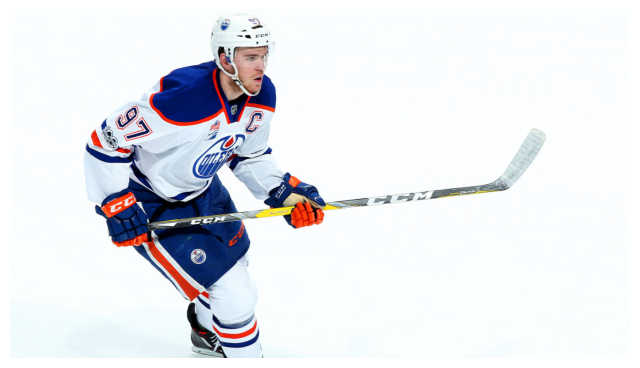

In [36]:
img_bgr = cv2.imread('lab1.jpg')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis('off')


(-0.5, 1279.5, 719.5, -0.5)

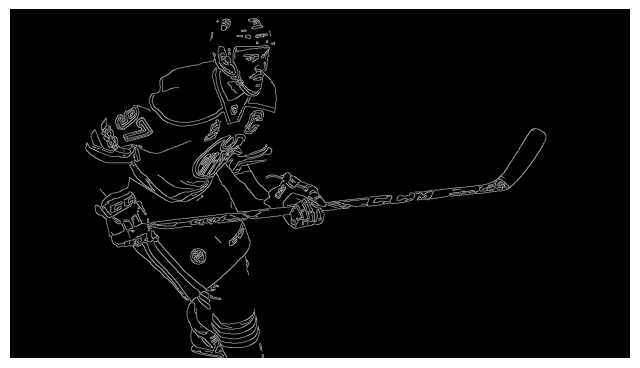

In [37]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap='gray')
plt.axis('off')


In [38]:
kernel = np.ones((7, 7), np.uint8)
mask = cv2.dilate(edges, kernel, iterations=2)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 1000
significant_contours = [c for c in contours if cv2.contourArea(c) > min_area]

all_points = np.vstack(significant_contours)
x, y, w, h = cv2.boundingRect(all_points)

print('Найден прямоугольник объекта:')
print(f'x={x}, y={y}, w={w}, h={h}')


Найден прямоугольник объекта:
x=150, y=13, w=963, h=707


(-0.5, 1279.5, 719.5, -0.5)

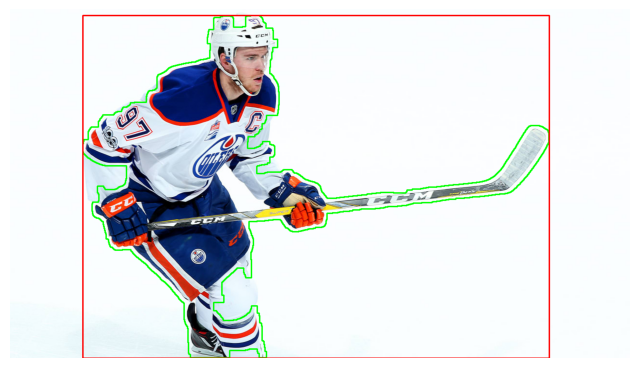

In [39]:
result = img_rgb.copy()

cv2.drawContours(result, significant_contours, -1, (0, 255, 0), 2)

cv2.rectangle(result, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(8, 6))
plt.imshow(result)
plt.axis('off')


In [40]:

def rectangle_numpy(image, pt1, pt2, color=(255, 0, 0), thickness=3):
    out = image.copy()

    h, w = out.shape[:2]

    x1, y1 = pt1
    x2, y2 = pt2
    left, right = sorted([x1, x2])
    top, bottom = sorted([y1, y2])

    left = max(0, min(left, w - 1))
    right = max(0, min(right, w - 1))
    top = max(0, min(top, h - 1))
    bottom = max(0, min(bottom, h - 1))

    thickness = max(1, int(thickness))

    out[top:top + thickness, left:right + 1] = color
    out[bottom - thickness + 1:bottom + 1, left:right + 1] = color
    out[top:bottom + 1, left:left + thickness] = color
    out[top:bottom + 1, right - thickness + 1:right + 1] = color

    return out


In [41]:
pt1 = (x, y)
pt2 = (x + w, y + h)

print('Координаты прямоугольника:', pt1, pt2)


Координаты прямоугольника: (150, 13) (1113, 720)


(-0.5, 1279.5, 719.5, -0.5)

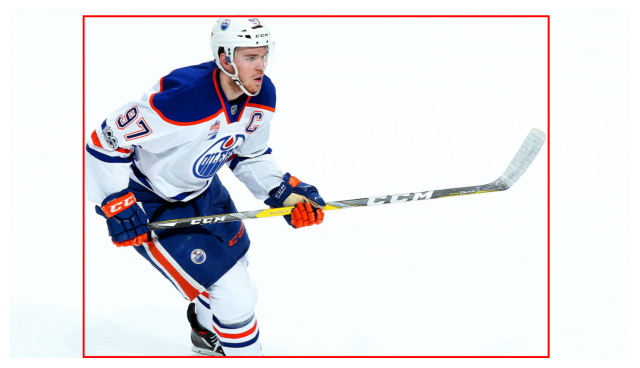

In [42]:
custom_rect_img = rectangle_numpy(
    image=img_rgb,
    pt1=pt1,
    pt2=pt2,
    color=(255, 0, 0),
    thickness=4
)

plt.figure(figsize=(8, 6))
plt.imshow(custom_rect_img)
plt.axis('off')
